*© 2026 Zettnq · oi-volume-signal-research · MIT License*
### 04. Event Selection
Constructing three event families (raw / episodes / confirmation) and comparing methodologies. Artifacts: events_raw/episodes/confirmation.parquet. Figure: figures/data/methodology_comparison.png.

In [1]:
from pathlib import Path

import oivdc_research  # installed via `pip install -e .`

# repo root: .../repo/src/oivdcr_research/__init__.py -> parents[2] = repo
PROJECT_ROOT = Path(oivdc_research.__file__).resolve().parents[2]

import numpy as np
import pandas as pd

from oivdc_research.config import get_config

# Reproducibility parameters — edit here.
ASSET = "btcusdt"
TIMEFRAME = "1h"

CONFIG = get_config(
    project_root=PROJECT_ROOT,
    raw_csv_path=PROJECT_ROOT / "data" / "raw" / f"{ASSET}_{TIMEFRAME}.csv",
    timeframe=TIMEFRAME,
    asset=ASSET,
)

In [2]:
from oivdc_research.forward_returns import load_forward_returns
from oivdc_research.event_selection import (
    build_events_raw,
    build_events_episodes,
    build_events_confirmation,
    get_event_selection_summary,
)

df = load_forward_returns(CONFIG)

events_raw = build_events_raw(df, CONFIG)
events_episodes = build_events_episodes(df, CONFIG)      # feasible entry (S2)
events_conf = build_events_confirmation(df, CONFIG)      # live-like (S3)

events_raw.to_parquet(CONFIG.events_raw_path, index=False)
events_episodes.to_parquet(CONFIG.events_episodes_path, index=False)
events_conf.to_parquet(CONFIG.events_confirmation_path, index=False)

print(get_event_selection_summary(events_raw, events_episodes))

        method signal_type  n_events
0  raw_signals        long      8263
1  raw_signals       short      8410
2     episodes        long     46228
3     episodes       short     48090


Saved: reports/figures/data/methodology_comparison.png


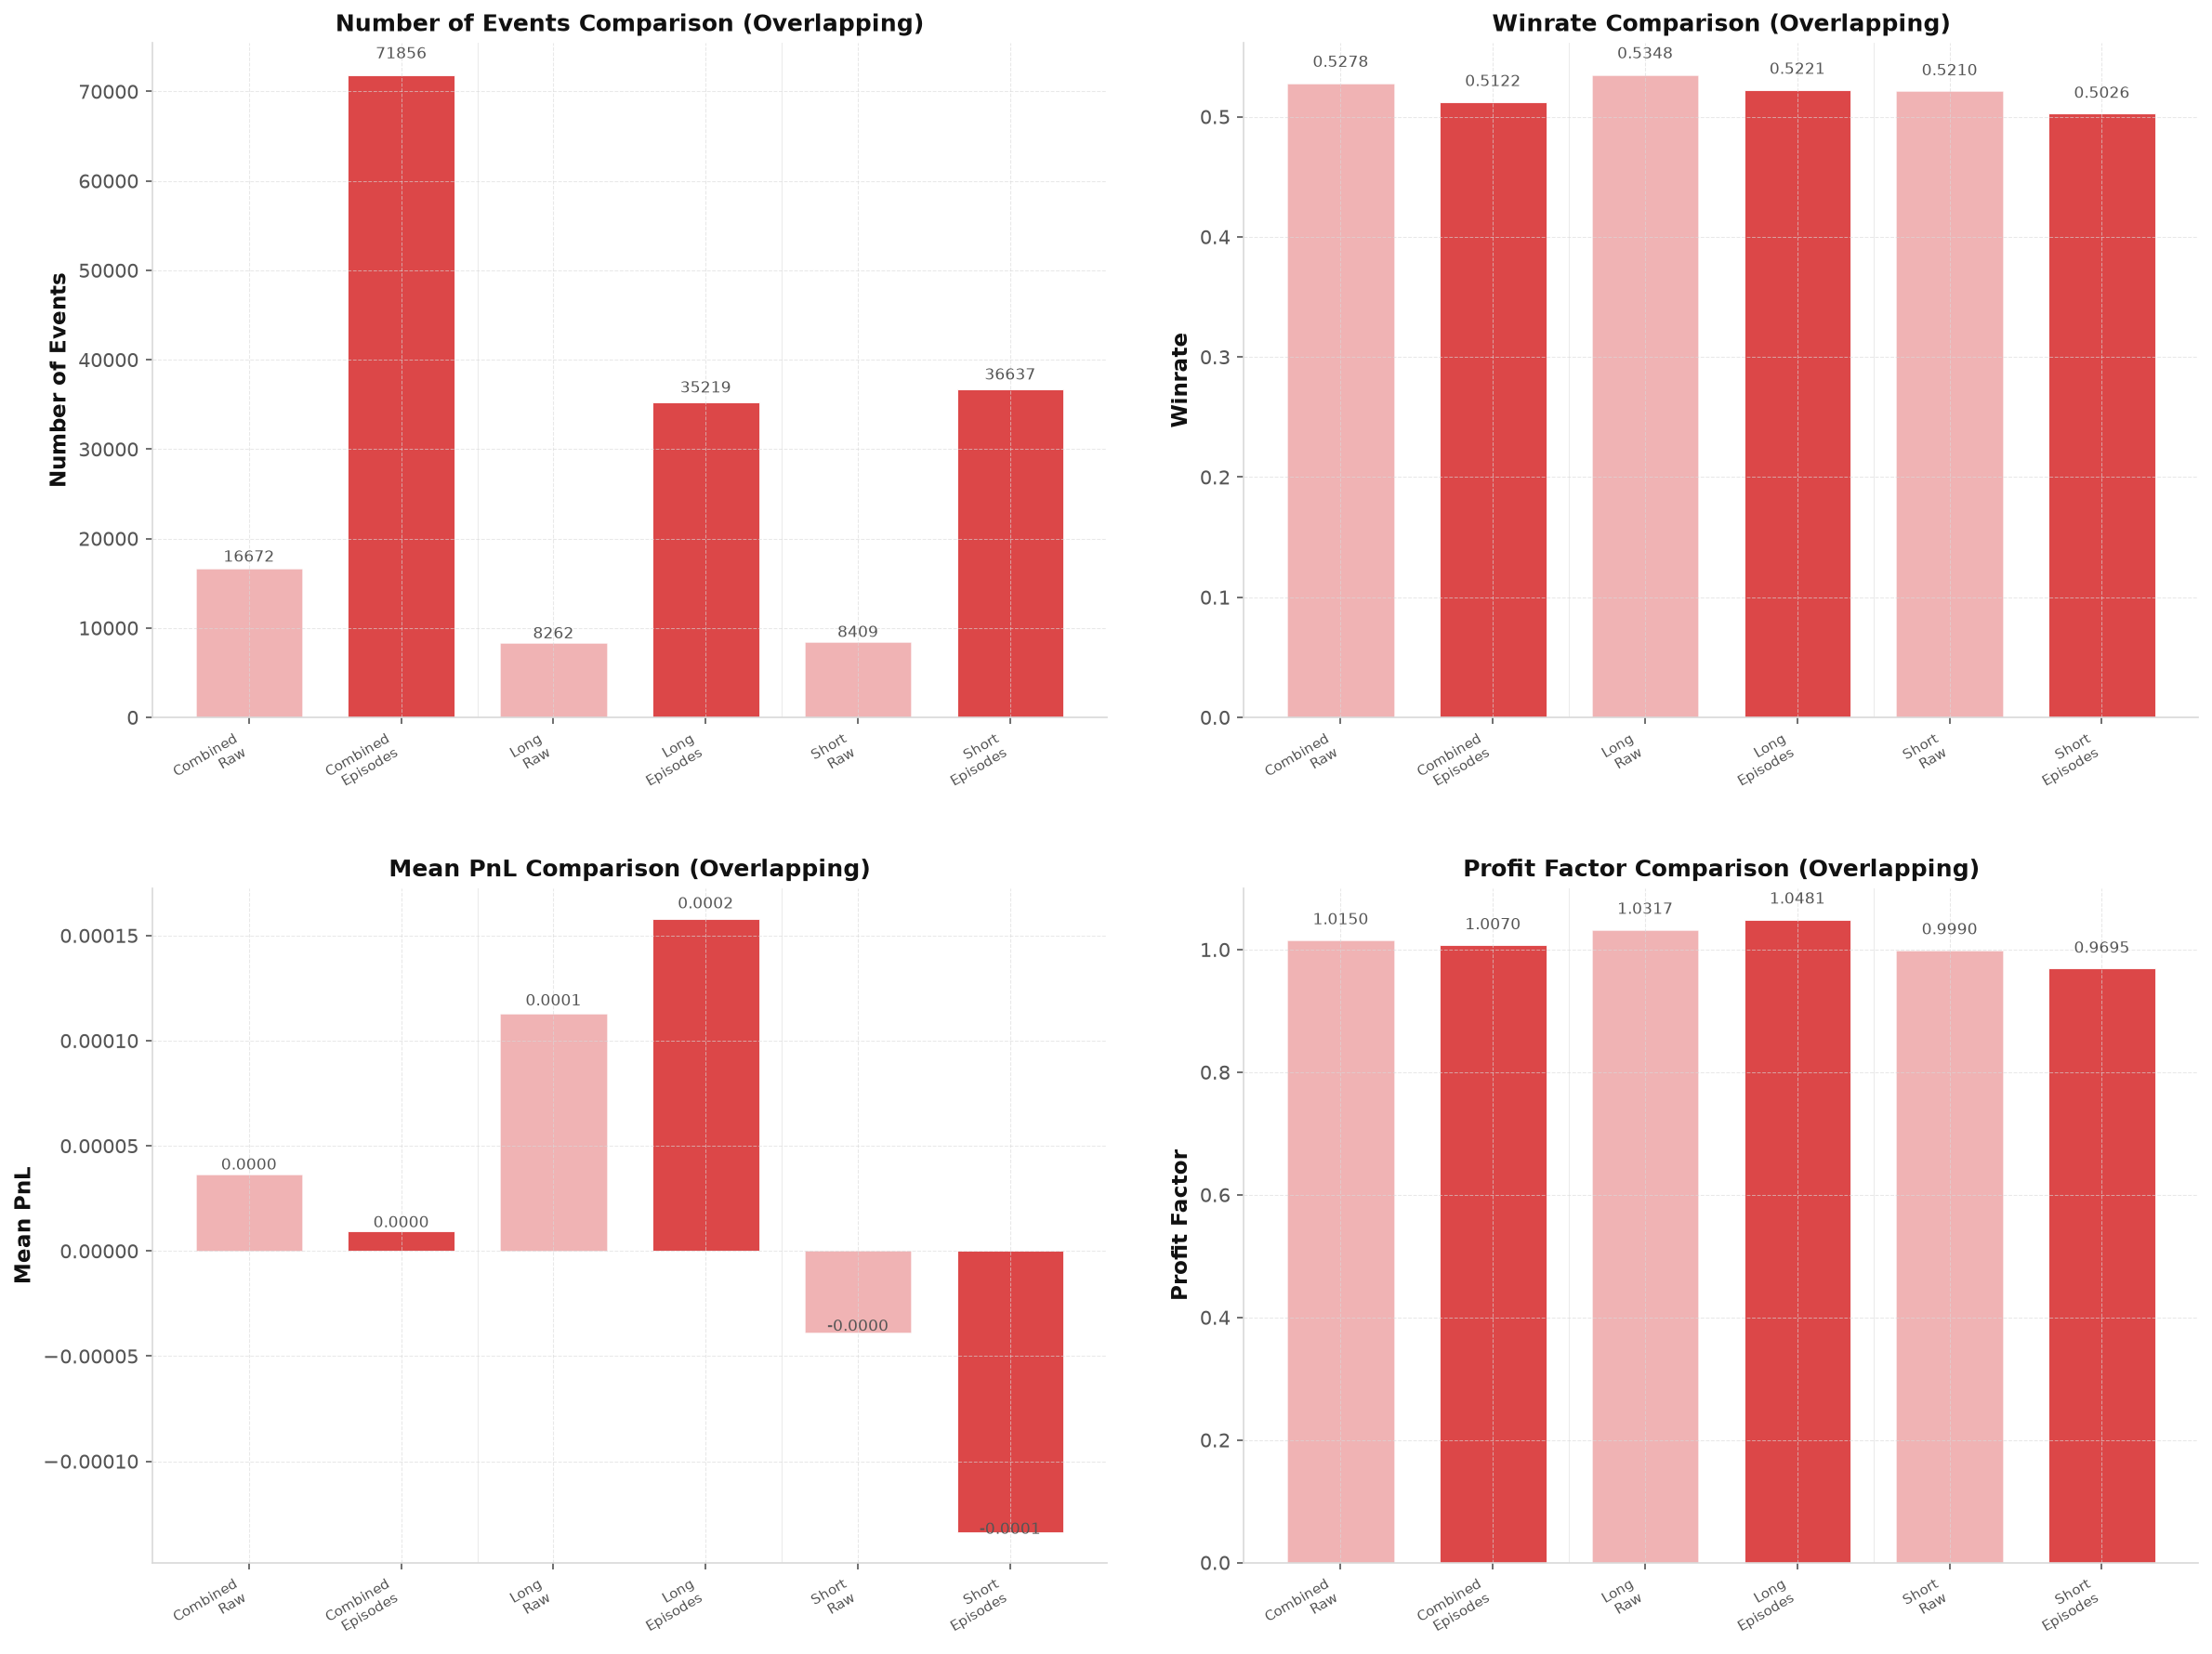

In [3]:
from oivdc_research.statistics import compute_statistics_for_events_wide
from oivdc_research.plotting import plot_methodology_comparison

stats = pd.concat([
    compute_statistics_for_events_wide(events_raw, CONFIG, "raw_signals", "overlapping"),
    compute_statistics_for_events_wide(events_episodes, CONFIG, "episodes", "overlapping"),
], ignore_index=True)

plot_methodology_comparison(stats, CONFIG,
                            CONFIG.figures_dir_for("data") / "methodology_comparison.png")

Episodic aggregation reduces N and removes dependencies within clusters; `build_events_episodes` uses the feasible input (open[t_end+2]) — this is S2. The oracle input (S1) is constructed in 05.